In [28]:
import os
import h5py
import numpy as np
from scipy.integrate import solve_ivp
from scipy.stats.qmc import Halton

# File paths
old_file_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/Old equations/datasets/trials_many_alldata_v3.h5"
new_file_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton.h5"

# Ensure the directory exists
new_dir = os.path.dirname(new_file_path)
os.makedirs(new_dir, exist_ok=True)

# Constants
P_c = 0.0653
phi = 0.279
h_e_range = [0.5, 1]
rho = 1e3
d_range = [2e-6, 5e-6]
l_range = [0.138e-3, 0.412e-3]
U_range = [0.056e-3, 0.099e-3]
ts_range = [1.75, 6.6]


# Function to calculate I
def calculate_I(h, f, I_0=1.0):
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)

# Differential equation system
def differential_system(t, y, J_e, b_1, b_2, h_e):
    h, c = y
    g_t = b_1 * np.exp(b_2 * t)
    dh_dt = -g_t * h - J_e * (1 - (h_e / h) ** 3) + P_c * (c-1)
    dc_dt = (J_e * (1 - (h_e / h) ** 3) - P_c * (c - 1)) * c / h
    return [dh_dt, dc_dt]


In [29]:
with h5py.File(old_file_path, 'r') as old_data:
    # Extract parameter values
    P_old = old_data['P'][:]
    J_e_primes = P_old[:, 0]
    b_1_primes = P_old[:, 1]
    b_2_primes = P_old[:, 2]
    f_0_primes = P_old[:, 6]

    # Find the shortest length
    min_length = min(len(J_e_primes), len(b_1_primes), len(b_2_primes), len(f_0_primes))
    # Function to randomly reduce the length of a list
    def reduce_length(arr, target_length):
        if len(arr) > target_length:
            indices = np.random.choice(len(arr), target_length, replace=False)
            return arr[indices]
        return arr

    # Reduce lengths to the shortest length
    J_e_primes = reduce_length(J_e_primes, min_length)
    b_1_primes = reduce_length(b_1_primes, min_length)
    b_2_primes = reduce_length(b_2_primes, min_length)
    f_0_primes = reduce_length(f_0_primes, min_length)
    f_cr = 5.3e-3
    f_0_values = f_0_primes/f_cr
    h_0_values = P_old[:, 4]

time_grid = np.linspace(0, 1, 601)

In [30]:
halton_sampler = Halton(d=1, scramble=False, seed=42)
halton_sequence = halton_sampler.random(n=111563).flatten()
# Rescale to be in the range 0.5 to 1.0
h_e_halton = h_e_range[0] + (h_e_range[1] - h_e_range[0]) * halton_sequence

d_halton = d_range[0] + (d_range[1] - d_range[0]) * halton_sequence

l_halton = l_range[0] + (l_range[1] - l_range[0]) * halton_sequence

U_halton = U_range[0] + (U_range[1] - U_range[0]) * halton_sequence

ts_halton = ts_range[0] + (ts_range[1] - ts_range[0]) * halton_sequence

J_e_values = J_e_primes * l_halton / (rho * d_halton * U_halton)

b_1_values = b_1_primes * ts_halton

b_2_values = b_2_primes * ts_halton

h_e_values = np.array(h_e_halton) / np.array(h_0_values)


In [ ]:
# Differential system (P_c is a constant and does not need to be passed as an argument)
def differential_system(t, y, J_e, b_1, b_2, h_e):
    h, c = y
    g_t = b_1 * np.exp(b_2 * t)
    dh_dt = -g_t * h - J_e * (1 - (h_e / h) ** 3) + P_c * (c - 1)
    dc_dt = (J_e * (1 - (h_e / h) ** 3) - P_c * (c - 1)) * c / h
    return [dh_dt, dc_dt]

def generate_and_store_dataset():
    valid_h, valid_c, valid_f, valid_I, valid_p = [], [], [], [], []
    
    for i, (J_e, b_1, b_2, h_e, f_0) in enumerate(zip(J_e_values, b_1_values, b_2_values, h_e_values, f_0_values)):
        y0 = [1.0, 1.0]  # Initial conditions: h(0) = 1.0, c(0) = 1.0
        sol = solve_ivp(differential_system, [0., 1.], y0, t_eval=time_grid, 
                        args=(J_e, b_1, b_2, h_e), method='RK45')
        
        if np.max(sol.y[0]) > 1.1:
            # print(f"{i}'th parameter set is rejected.")
            continue  # Discard solutions where h exceeds 1.1
        
        # print(f"{i}'th parameter set is accepted.")
        h_values = sol.y[0]
        c_values = sol.y[1]
        f_values = f_0 * c_values
        I_values = calculate_I(h_values, f_values)
        
        valid_h.append(h_values)
        valid_c.append(c_values)
        valid_f.append(f_values)
        valid_I.append(I_values)
        valid_p.append([J_e, b_1, b_2, h_e * h_0_values[i]])  # Store h_e_prime instead of h_e

    # Convert lists to NumPy arrays
    valid_h = np.array(valid_h)
    valid_c = np.array(valid_c)
    valid_f = np.array(valid_f)
    valid_I = np.array(valid_I)
    valid_p = np.array(valid_p)

    # Save data in HDF5 format
    with h5py.File(new_file_path, "w") as hdf_file:
        hdf_file.create_dataset("h", data=valid_h)
        hdf_file.create_dataset("c", data=valid_c)
        hdf_file.create_dataset("f", data=valid_f)
        hdf_file.create_dataset("I", data=valid_I)
        hdf_file.create_dataset("p", data=valid_p)
        
    print(f"Total accepted parameter sets: {valid_h.shape[0]}")


In [32]:
generate_and_store_dataset()

0'th parameter set is accepted.
1'th parameter set is accepted.
2'th parameter set is accepted.
3'th parameter set is accepted.
4'th parameter set is accepted.
5'th parameter set is rejected.
6'th parameter set is accepted.
7'th parameter set is accepted.


KeyboardInterrupt: 

In [ ]:
# # Main function
# def generate_dataset():
#     with h5py.File(old_file_path, 'r') as old_data, h5py.File(new_file_path, 'w') as new_data:
#         # Extract parameter values
#         P_old = old_data['P'][:]
#         J_e_primes = P_old[:, 0]
#         b_1_primes = P_old[:, 1]
#         b_2_primes = P_old[:, 2]
#         f_0_primes = P_old[:, 6]

#         # Find the shortest length
#         min_length = min(len(J_e_primes), len(b_1_primes), len(b_2_primes), len(f_0_primes))
#         # Function to randomly reduce the length of a list
#         def reduce_length(arr, target_length):
#             if len(arr) > target_length:
#                 indices = np.random.choice(len(arr), target_length, replace=False)
#                 return arr[indices]
#             return arr

#         # Reduce lengths to the shortest length
#         J_e_primes = reduce_length(J_e_primes, min_length)
#         b_1_primes = reduce_length(b_1_primes, min_length)
#         b_2_primes = reduce_length(b_2_primes, min_length)
#         f_0_primes = reduce_length(f_0_primes, min_length)
#         f_cr = 5.3e-3
#         f_0_values = f_0_primes/f_cr
#         h_0_values = P_old[:, 4]
#         time_grid = np.linspace(0, 1, 601)

#         # Create datasets in the new file
#         new_h = new_data.create_dataset("h", (0, len(time_grid)), maxshape=(None, len(time_grid)))
#         new_c = new_data.create_dataset("c", (0, len(time_grid)), maxshape=(None, len(time_grid)))
#         new_f = new_data.create_dataset("f", (0, len(time_grid)), maxshape=(None, len(time_grid)))
#         new_I = new_data.create_dataset("I", (0, len(time_grid)), maxshape=(None, len(time_grid)))
#         new_P = new_data.create_dataset("P", (0, P_old.shape[1] + 1), maxshape=(None, P_old.shape[1] + 1))

#         # Iterate over parameter sets
#         count = 0
#         accepeted_parameter = 0
#         accepeted_parameter_index = []
#         rejected_parameter = 0
#         rejected_parameter_index = []
        
#         # Generate Halton sequence
#         halton_sampler = Halton(d=1, scramble=False)

#         # Rescale to be in the range 0.5 to 1.0
#         h_e_halton = h_e_range[0] + (h_e_range[1] - h_e_range[0]) * halton_sampler.random(n=111563).flatten()
        
#         d_halton = d_range[0] + (d_range[1] - d_range[0]) * halton_sampler.random(n=111563).flatten()
        
#         l_halton = l_range[0] + (l_range[1] - l_range[0]) * halton_sampler.random(n=111563).flatten()
        
#         U_halton = U_range[0] + (U_range[1] - U_range[0]) * halton_sampler.random(n=111563).flatten()
        
#         ts_halton = ts_range[0] + (ts_range[1] - ts_range[0]) * halton_sampler.random(n=111563).flatten()
        
#         J_e_values = J_e_primes * l_halton / (rho * d_halton * U_halton)
        
#         b_1_values = b_1_primes * ts_halton
        
#         b_2_values = b_2_primes * ts_halton
        
#         for i, (J_e, b_1, b_2, f_0, h_0) in enumerate(zip(J_e_values, b_1_values, b_2_values, f_0_values, h_0_values)):
#             while count < 2:
#                 # Randomly choose h_e
#                 h_e_prime = h_e_halton[i]
#                 h_e = h_e_prime/h_0

#                 # Solve the differential equations
#                 y0 = [1, 1]
#                 sol = solve_ivp(
#                     differential_system,
#                     [time_grid[0], time_grid[-1]],
#                     y0,
#                     t_eval=time_grid,
#                     args=(J_e, b_1, b_2, h_e),
#                     method='RK45'
#                 )

#                 h, c = sol.y
#                 f = f_0 * c
#                 I = calculate_I(h, f)

#                 # Check acceptability
#                 if np.all(h <= 1.1):
#                     # Data is acceptable, save it
#                     new_h.resize(new_h.shape[0] + 1, axis=0)
#                     new_c.resize(new_c.shape[0] + 1, axis=0)
#                     new_f.resize(new_f.shape[0] + 1, axis=0)
#                     new_I.resize(new_I.shape[0] + 1, axis=0)
#                     new_P.resize(new_P.shape[0] + 1, axis=0)

#                     new_h[-1] = h
#                     new_c[-1] = c
#                     new_f[-1] = f
#                     new_I[-1] = I

#                     # Append parameter values including h_e
#                     new_P[-1] = np.append(P_old[i], h_e)
#                     accepeted_parameter += 1
#                     accepeted_parameter_index.append(i)
#                     print(f"{h_e} is accepted")
#                     count = 0
#                     break
#                 else:
#                     count += 1
#             if count == 2:
#                 print("Suitable h_e was not found")
#                 rejected_parameter += 1
#                 rejected_parameter_index.append(i)
#                 count = 0

#             print(f"Processed parameter set {i + 1}/{len(J_e_values)}, {accepeted_parameter} parameters has been accepted.")

#     print(f"Dataset generation completed and saved to: {new_file_path}, accepted parameters = {accepeted_parameter}, rejected parameters = {rejected_parameter}")
    
#     return accepeted_parameter, accepeted_parameter_index, rejected_parameter, rejected_parameter_index

# # Run the function
# accepeted_parameter, accepeted_parameter_index, rejected_parameter, rejected_parameter_index = generate_dataset()


0.1509433962264151 is accepted
Processed parameter set 1/111563, 1 parameters has been accepted.
0.10619469026548672 is accepted
Processed parameter set 2/111563, 2 parameters has been accepted.
0.6451612903225806 is accepted
Processed parameter set 3/111563, 3 parameters has been accepted.
0.18543046357615894 is accepted
Processed parameter set 4/111563, 4 parameters has been accepted.
0.1978021978021978 is accepted
Processed parameter set 5/111563, 5 parameters has been accepted.
Suitable h_e was not found
Processed parameter set 6/111563, 5 parameters has been accepted.
0.15331010452961671 is accepted
Processed parameter set 7/111563, 6 parameters has been accepted.
0.3592814371257485 is accepted
Processed parameter set 8/111563, 7 parameters has been accepted.
0.08353808353808354 is accepted
Processed parameter set 9/111563, 8 parameters has been accepted.
0.4672897196261682 is accepted
Processed parameter set 10/111563, 9 parameters has been accepted.
0.12103746397694524 is accept

KeyboardInterrupt: 

In [ ]:
import torch
import os
import h5py
import numpy as np
from scipy.integrate import solve_ivp

In [ ]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton.h5", 'r')
data_I = np.array(datastore["I"])
data_h = np.array(datastore["h"])
data_f = np.array(datastore["f"])

data_c = np.array(datastore["c"])

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
# device = "cpu"
print(f"Using {device} device")

Using cpu device


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
t = np.linspace(0,1,601)

90650


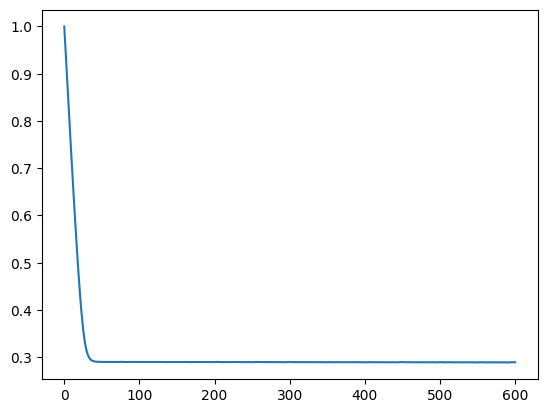

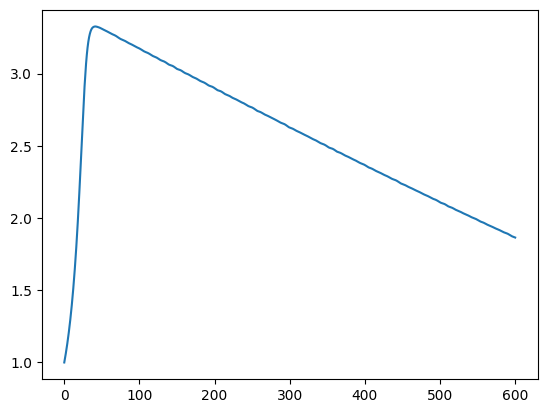

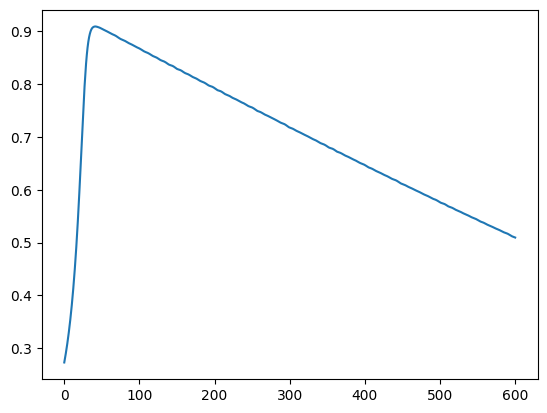

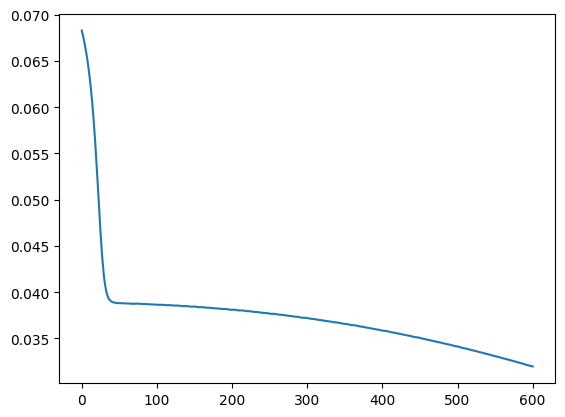

In [ ]:
n = np.random.randint(0, 111563)
print(n)
plt.plot(data_h[n])
plt.show()
plt.plot(data_c[n])
plt.show()
plt.plot(data_f[n])
plt.show()
plt.plot(data_I[n])
plt.show()

15439


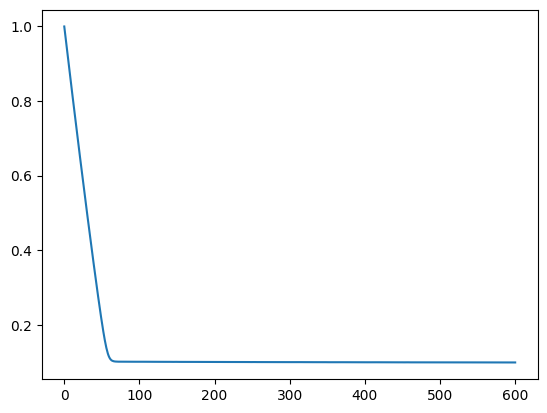

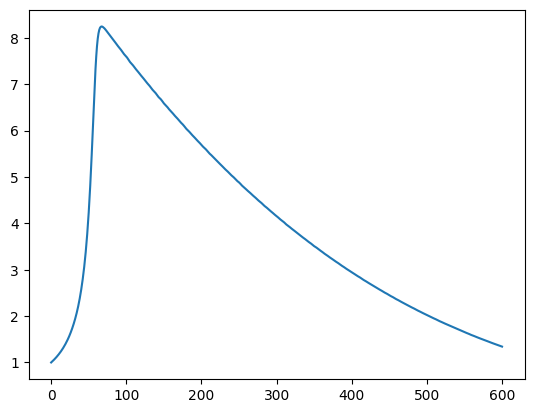

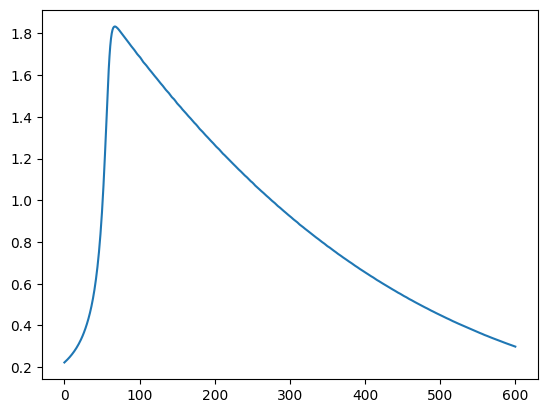

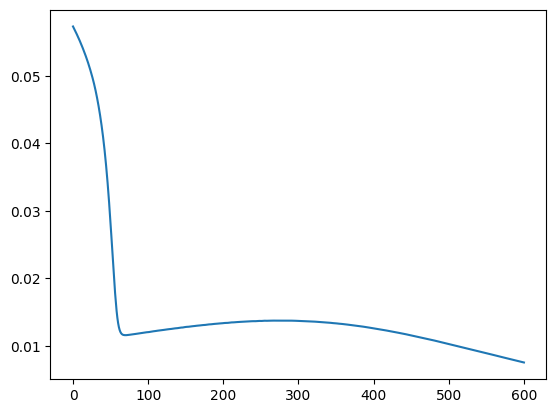

In [ ]:
n = np.random.randint(0, 111563)
print(n)
plt.plot(data_h[n])
plt.show()
plt.plot(data_c[n])
plt.show()
plt.plot(data_f[n])
plt.show()
plt.plot(data_I[n])
plt.show()

In [ ]:
n = np.random.randint(0, 111563)
print(n)
plt.plot(data_h[n])
plt.show()
plt.plot(data_c[n])
plt.show()
plt.plot(data_f[n])
plt.show()
plt.plot(data_I[n])
plt.show()

110174


IndexError: index 110174 is out of bounds for axis 0 with size 108720